# Lab Work - 2.6

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

np.random.seed(42)

# Q1 Visualizing Non-Linear Data

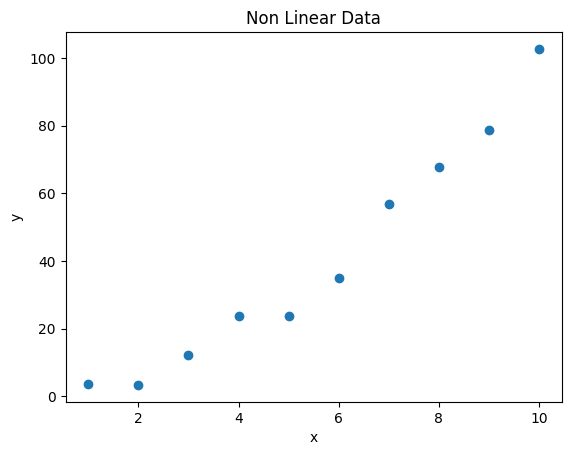

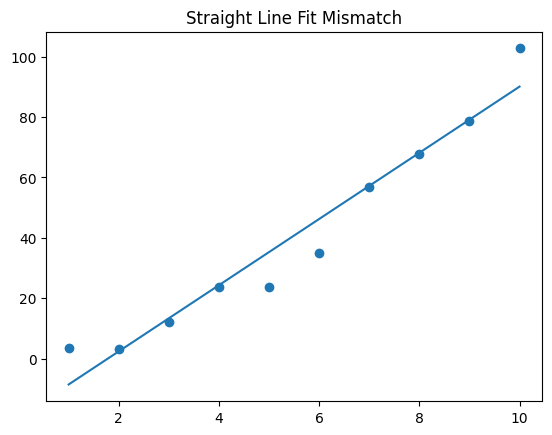

In [2]:
x=np.arange(1,11).reshape(-1,1)

noise=np.random.randn(10,1)*5

y=x**2+noise

plt.scatter(x,y)
plt.title('Non Linear Data')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

linear=LinearRegression()
linear.fit(x,y)

plt.scatter(x,y)
plt.plot(x,linear.predict(x))
plt.title('Straight Line Fit Mismatch')
plt.show()

# Q2 Manual Feature Expansion

In [3]:
x=np.array([1,2,3,4])

manual=np.column_stack((np.ones(len(x)),x,x**2))

print('Polynomial Matrix')
print(manual)

Polynomial Matrix
[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]]


# Q3 Polynomial Regression Model

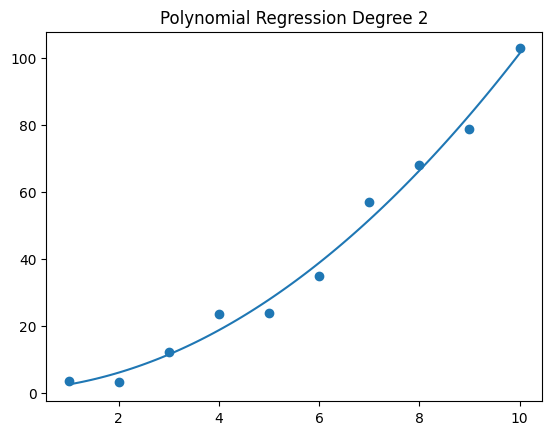

In [4]:
x=np.arange(1,11).reshape(-1,1)

poly=PolynomialFeatures(degree=2)

x_poly=poly.fit_transform(x)

model=LinearRegression()

model.fit(x_poly,y)

x_range=np.linspace(1,10,100).reshape(-1,1)

pred=model.predict(poly.transform(x_range))

plt.scatter(x,y)
plt.plot(x_range,pred)
plt.title('Polynomial Regression Degree 2')
plt.show()

# Q4 Degree Comparison

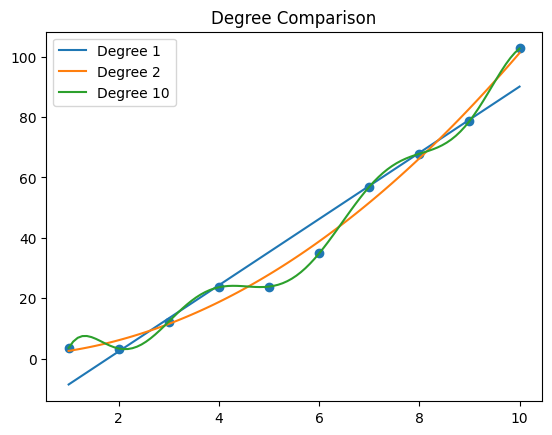

Degree1 = Underfitting
Degree2 = Good Fit
Degree10 = Overfitting


In [5]:
degrees=[1,2,10]

plt.scatter(x,y)

for d in degrees:
    poly=PolynomialFeatures(degree=d)
    x_poly=poly.fit_transform(x)

    model=LinearRegression()
    model.fit(x_poly,y)

    y_pred=model.predict(poly.transform(x_range))

    plt.plot(x_range,y_pred,label='Degree '+str(d))

plt.legend()
plt.title('Degree Comparison')
plt.show()

print('Degree1 = Underfitting')
print('Degree2 = Good Fit')
print('Degree10 = Overfitting')

# Q5 Predict New Value

In [6]:
new=np.array([[6.5]])

prediction=model.predict(poly.transform(new))

print('Prediction at x=6.5')
print(prediction)

Prediction at x=6.5
[[46.02085631]]


# Q6 Real Dataset Simulation

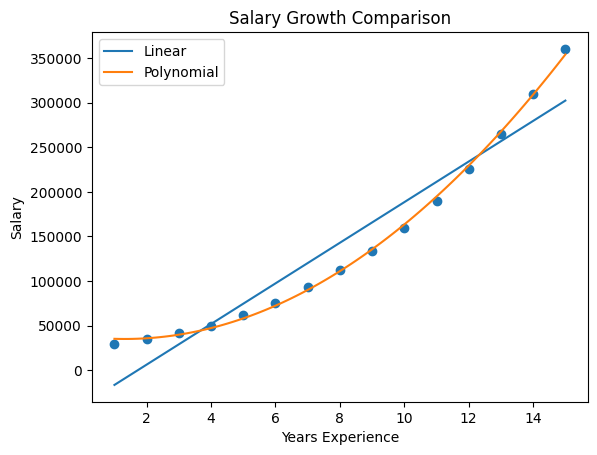

In [7]:
experience=np.arange(1,16).reshape(-1,1)

salary=np.array([
30000,
35000,
42000,
50000,
62000,
76000,
93000,
112000,
134000,
160000,
190000,
225000,
265000,
310000,
360000
])

linear=LinearRegression()
linear.fit(experience,salary)

poly=PolynomialFeatures(degree=2)

exp_poly=poly.fit_transform(experience)

poly_model=LinearRegression()

poly_model.fit(exp_poly,salary)

x_range=np.linspace(1,15,100).reshape(-1,1)

plt.scatter(experience,salary)

plt.plot(
x_range,
linear.predict(x_range),
label='Linear'
)

plt.plot(
x_range,
poly_model.predict(
poly.transform(x_range)
),
label='Polynomial'
)

plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.legend()
plt.title('Salary Growth Comparison')
plt.show()